In [2]:
# %%
# Cell 01 - Setup imports
# Adds repo src path and imports shared loading, analysis, plotting, and multi-fish helpers.

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import importlib

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.data_loading as exio
import src.analysis_tools as at
import seaborn as sns
import importlib
import numpy as np
from pathlib import Path
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.cluster.hierarchy import linkage, fcluster, leaves_list
from scipy.spatial.distance import pdist
from sklearn.cluster import KMeans
import seaborn as sns
import src.stimuli_timeline as st
import src.plotting as plott
import src.data_loading as exio
import src.analysis_tools as at
from src.multifish_analysis import (
    build_active_neuron_matrices_all_fish,
    build_active_neuron_overlap_matrices_all_fish,
    build_pooled_active_trace_diagnostic,
)


## Cell 02 - Setup notes
Markdown separator for the import/setup section.


In [3]:
# %%
# Cell 03 - Load and align fish
# Defines experiment paths, fish list, and a loader that builds aligned dFoF, raster, normalized, and z-score traces.
### ==== CONFIG GENERAL (común a todos los peces) ===============================

experiment_name = "Exp_5_map_positions"#"Exp_2_rocking_1" #"Exp_3_rocking_2"
main_path = Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p")
analysis_path= Path(r"D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Analysis")
stimuli_main_path = analysis_path
save_path= analysis_path / experiment_name / "plots"

fps_2p = 2.0
selected_blocks = [f"B{n}" for n in range(1, 5)]

t_pre_s  = 5.0   # time before onset to include
t_post_s = 25.0  # time after onset to include

# left (1,3,4,9,10)
#`right (1,5,6,9,10)`

# Lista de peces que quieres procesar
fish_ids = [
    "L684_f01",
    #"L684_f06",
    "L684_f07",
    "L733_f01",
    #"L733_f02",
    #"L733_f03",
    #"L733_f04",
    #"L733_f05",
    "L733_f06",
    "L733_f07"    

]

importlib.reload(exio)
importlib.reload(at)

def load_and_align_one_fish(
    fish_id: str,
    experiment_name: str,
    main_path: Path,
    stimuli_main_path: Path,
    fps_2p: float,
    selected_blocks,
    t_pre_s: float,
    t_post_s: float,
):
    """Carga un experimento de un pez y calcula las trial-aligned traces.
    Devuelve TODO lo que quieres para usar después.
    """
    # ==== LOAD EVERYTHING IN ONE GO =========================================
    results = exio.load_2p_experiment(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
    )

    dfof              = results["dfof"]
    stimuli_trace_60  = results["stimuli_trace_60"]
    stimuli_id_map    = results["stimuli_id_map"]
    raster            = results["raster"]
    dfof_center       =results["deltaF_center"]
    dFoF_merged_map    =   results["dFoF_merged_map"]
    stimuli_durations = results["stimuli_durations"]
    kept_neuron_indices = results["kept_neuron_indices"]
    z_traces = results["z_traces"]

        # NEW: normalizar dfof_center a [0, 1] globalmente
    min_val = np.nanmin(dfof_center)          # NEW
    max_val = np.nanmax(dfof_center)          # NEW
    rng = max_val - min_val + 1e-12           # NEW (evita división por cero)

    dfof_center_norm = (dfof_center - min_val) / rng   # NEW


    # ==== BUILD TRIAL-ALIGNED TRACES ========================================
    res = at.build_trial_aligned_traces(
        dfof=dfof,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED TRACES Signf========================================
    res_raster = at.build_trial_aligned_traces(
        dfof=raster,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    ##==== BUILD TRIAL-ALIGNED Norm_Df/F========================================

    res_norm = at.build_trial_aligned_traces(
        dfof=dfof_center_norm,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    # ==== BUILD TRIAL-ALIGNED Z-core =======================================
    res_zcore = at.build_trial_aligned_traces(
        dfof=z_traces,
        stimuli_trace_60=stimuli_trace_60,
        fps_2p=fps_2p,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
        stimuli_id_map=stimuli_id_map,  # or None
        verbose=True,
    )

    return {
        "trial_aligned_traces": res["trial_aligned_traces"],  # dict: stim_id -> (n_neurons, n_trials, frames)
        "stimuli_ids":          res["stimuli_ids"],           # list
        "stimuli_names":        res["stimuli_names"],         # list
        "win_length":           res["win_length"],            # int
        "stimuli_trace":        res["stimuli_trace"],         # (n_frames_total,)
        "onsets_by_id":         res["onsets_by_id"],          # dict: stim_id -> (n_trials,)
        "trial_aligned_traces_raster": res_raster["trial_aligned_traces"],
        "trial_aligned_traces_norm": res_norm["trial_aligned_traces"],
        "trial_aligned_traces_z_core": res_zcore["trial_aligned_traces"],

        # row data
        "dfof":                  dfof,
        "raster":                raster,
        "dfof_center":           dfof_center,
        "dFoF_merged_map":       dFoF_merged_map,
        "stimuli_durations":     stimuli_durations,
        "kept_neuron_indices":   kept_neuron_indices,
        "stimuli_id_map":         stimuli_id_map,
        # si más tarde quieres acceder a cosas del results original:
        "meta": {
            "frames_per_block":       results["frames_per_block"],
            "duration_2p_block_sec":  results["duration_2p_block_sec"],
            "paths":                  results["paths"],
            "plane_ids":              results["plane_ids"],
            "stat_per_plane":         results["stat_per_plane"],
            # etc, añade aquí lo que te haga falta
        }
    }


# ==== PROCESAR TODOS LOS PECES ==============================================
all_fish_data = {}

for fish_id in fish_ids:
    print(f"\n=== Procesando pez {fish_id} ===")
    all_fish_data[fish_id] = load_and_align_one_fish(
        fish_id=fish_id,
        experiment_name=experiment_name,
        main_path=main_path,
        stimuli_main_path=stimuli_main_path,
        fps_2p=fps_2p,
        selected_blocks=selected_blocks,
        t_pre_s=t_pre_s,
        t_post_s=t_post_s,
    )

print("Listo, todos los peces procesados.")



=== Procesando pez L684_f01 ===
Loaded significant traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\significant_traces\L684_f01_significant_traces.npz
Loaded kept_neuron_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\filtered_neurons_by_stimuli\L684_f01_kept_neuron_indices.npy
Loaded filtered_roi_indices from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_dFoF\L684_f01_dFoF_merged_filtered_roi_indices.npy
Loaded z_traces from D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\plots\z_core\L684_f01_zcore.npz
Using canonical merged map file: D:\Alejandro\Data\OneDrive - Université de Lausanne\Lab\Data\2p\L684_f01_Exp_5_map_positions\03_analysis\functional\suite2P\merged_

## Cell 04 - Style notes
Markdown separator before stimulus styling configuration.


In [10]:
# Cell 05 - Stimulus styles
# Defines colors, line styles, display order, and peri-stimulus plotting windows.
# select colors and linestyles for stimuli
# --- Set A (default)

colors_C = {
    'FlickL': sns.color_palette('dark:#404040', 10)[7],
    'FlickR': sns.color_palette('dark:#404040', 10)[7],
    'LeB1': sns.color_palette('Blues', 8)[7],
    'LeB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'LeB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'RiB1': sns.color_palette('Blues', 8)[7],
    'RiB2': sns.color_palette('Greens', as_cmap=True)(0.4),
    'RiB3': sns.color_palette('PuRd', as_cmap=True)(0.9),
    'LeB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'RiB4': sns.color_palette('Reds', as_cmap=True)(0.9),
    'LeBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RiBcontrol': sns.color_palette('Greens', as_cmap=True)(0.9),
    'RockL': sns.color_palette('PuRd', as_cmap=True)(0.6),
    'RockR': sns.color_palette('PuRd', as_cmap=True)(0.6),
}
linestyles_C = {
    'FlickR': '--',
    'RiB1': '--',
    'RiB2': '--',
    'RiB3': '--',
    'RiB4': '--',
    'RiBcontrol': '--',
    'RockR': '--',
}

stimuli_colors = colors_C
stimuli_linestyles = linestyles_C

# --- choose stimulus-aligned windows ---
window_pre = 5  # seconds before stimulus
window_post = 17  # seconds after stimulus

stimuli_ordered = [
    'LeBcontrol',
    'RiBcontrol',
    'LeB1',
    'LeB2',
    'LeB3',
    'LeB4',
    'RiB1',
    'RiB2',
    'RiB3',
    'RiB4',
    'RockL',
    'RockR',
    'FlickL',
    'FlickR'
]
print("Using colors for:", experiment_name)
print(stimuli_linestyles)

Using colors for: Exp_5_map_positions
{'FlickR': '--', 'RiB1': '--', 'RiB2': '--', 'RiB3': '--', 'RiB4': '--', 'RiBcontrol': '--', 'RockR': '--'}


In [11]:
# Cell 06 - Matrix builders
# Combines stimulus repetitions and stacks selected traces across all fish into one analysis matrix.
def combine_reps_one_stim(arr, mode="concat"):
    """
    arr: (n_neurons, n_time, n_reps)
    mode: "concat" or "mean"

    Returns:
        if mode == "concat": (n_neurons, n_time * n_reps)
        if mode == "mean":   (n_neurons, n_time)
    """
    assert arr.ndim == 3, "Expected 3D array (neurons, time, reps)"
    n_neurons, n_time, n_reps = arr.shape

    if mode == "concat":
        # (N, T, R) -> (N, R, T) -> (N, R*T)
        arr_swapped = np.swapaxes(arr, 1, 2)          # (n_neurons, n_reps, n_time)
        out = arr_swapped.reshape(n_neurons, n_reps * n_time)
        return out

    elif mode == "mean":
        # average across reps axis
        out = np.nanmean(arr, axis=2)                 # (n_neurons, n_time)
        return out

    else:
        raise ValueError(f"Unknown mode '{mode}', use 'concat' or 'mean'")


def build_matrix_for_fish(trial_aligned_traces,
                          stim_order,
                          kept_neuron_indices=None,
                          combine_mode="concat"):
    """
    trial_aligned_traces: dict[stim_id] -> array (neurons, time, reps)
    stim_order: list with desired stimulus order
    kept_neuron_indices: 1D array/list of neuron indices to keep, or None
    combine_mode: "concat" or "mean"
    """
    blocks = []

    for stim in stim_order:
        # Handle int vs str keys
        if stim in trial_aligned_traces:
            arr = trial_aligned_traces[stim]
        else:
            arr = trial_aligned_traces[str(stim)]

        # 🔴 HERE we apply your kept_neuron_indices
        if kept_neuron_indices is not None:
            arr = arr[kept_neuron_indices, :, :]

        arr_block = combine_reps_one_stim(arr, mode=combine_mode)  # (N, T*reps)
        blocks.append(arr_block)

    # Concatenate horizontally along time
    fish_mat = np.concatenate(blocks, axis=1)   # (N, sum_j T_j * reps_j)
    return fish_mat

def build_matrix_all_fish(
    all_fish_data,
    stim_order,
    fish_ids=None,
    combine_mode="concat",
    trace_type="dfof",
):
    """
    all_fish_data[fish_id][...] -> dict[stim] -> (neurons, time, reps)

    Parameters
    ----------
    all_fish_data : dict
        Per-fish data container.
    stim_order : list
        Stimulus order to use when building the matrix.
    fish_ids : list, optional
        Fish IDs to include. If None, use all fish in all_fish_data.
    combine_mode : str, default="concat"
        Passed to build_matrix_for_fish.
    trace_type : str, default="dfof"
        Which trace representation to use:
        - "dfof"   -> trial_aligned_traces
        - "raster" -> trial_aligned_traces_raster
        - "zscore" -> trial_aligned_traces_z_core

    Returns
    -------
    M_all : np.ndarray
        Shape (sum_neurons_all_fish, total_time)
    """
    if fish_ids is None:
        fish_ids = list(all_fish_data.keys())

    mats = []
    for fid in fish_ids:

        if trace_type == "raster":
            trial_key = "trial_aligned_traces_raster"
            kept_idx = None   # already filtered for raster version

        elif trace_type == "zscore":
            trial_key = "trial_aligned_traces_z_core"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        elif trace_type == "dfof":
            trial_key = "trial_aligned_traces"
            kept_idx = all_fish_data[fid]["kept_neuron_indices"]

        else:
            raise ValueError(
                f"Unknown trace_type={trace_type!r}. "
                "Use 'dfof', 'raster', or 'zscore'."
            )

        trial_aligned_traces = all_fish_data[fid][trial_key]

        M_fish = build_matrix_for_fish(
            trial_aligned_traces=trial_aligned_traces,
            stim_order=stim_order,
            kept_neuron_indices=kept_idx,
            combine_mode=combine_mode,
        )
        mats.append(M_fish)

    M_all = np.vstack(mats)

    return M_all

In [12]:
# Cell 07 - Inspect fish metadata
# Selects one fish and prints stimulus ID/duration mappings used by later plots.
fish_id = fish_ids[1]
trial_aligned_traces = all_fish_data[fish_id]["trial_aligned_traces"]
stimuli_id_map = all_fish_data[fish_id]["stimuli_id_map"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
stimuli_ids = all_fish_data[fish_id]["stimuli_ids"]
stimuli_names = all_fish_data[fish_id]["stimuli_names"]
stimuli_durations = all_fish_data[fish_id]["stimuli_durations"]
onsets_by_id = all_fish_data[fish_id]["onsets_by_id"]
print(stimuli_id_map)
print(stimuli_durations)

{'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}
{'FlickL': {'static_before_sec': 8.0, 'motion_sec': 1.9, 'static_after_sec': 0, 'total_sec': 9.9, 'total_frames': 594, 'motion_start_frame': 480, 'motion_end_frame': 594, 'start_frame': 480, 'end_frame': 594}, 'FlickR': {'static_before_sec': 8.0, 'motion_sec': 1.9, 'static_after_sec': 0, 'total_sec': 9.9, 'total_frames': 594, 'motion_start_frame': 480, 'motion_end_frame': 594, 'start_frame': 480, 'end_frame': 594}, 'LeB1': {'static_before_sec': 8.0, 'motion_sec': 1.883, 'static_after_sec': 0, 'total_sec': 9.883333333333333, 'total_frames': 593, 'motion_start_frame': 480, 'motion_end_frame': 593, 'start_frame': 480, 'end_frame': 593}, 'LeB2': {'static_before_sec': 8.0, 'motion_sec': 1.883, 'static_after_sec': 0, 'total_sec': 9.883333333333333, 'total_frames': 593, 'motion_start_frame': 480, 'motion_end_frame': 5

In [13]:
# Cell 08 - Count pooled neurons
# Prints kept-neuron counts and row ranges for each fish in pooled matrices.
counts = {
    fid: len(fish["kept_neuron_indices"])
    for fid, fish in all_fish_data.items()
}

running_total = 0

for fid, n_neurons in counts.items():
    start_row = running_total
    running_total += n_neurons
    end_row = running_total - 1

    print(
        f"{fid}: {n_neurons} neurons | "
        f"rows {start_row}-{end_row} | "
        f"cumulative total = {running_total}"
    )

print("Final total:", running_total)


L684_f01: 254 neurons | rows 0-253 | cumulative total = 254
L684_f07: 163 neurons | rows 254-416 | cumulative total = 417
L733_f01: 353 neurons | rows 417-769 | cumulative total = 770
L733_f06: 485 neurons | rows 770-1254 | cumulative total = 1255
L733_f07: 410 neurons | rows 1255-1664 | cumulative total = 1665
Final total: 1665


Final matrix shape: (1665, 420)


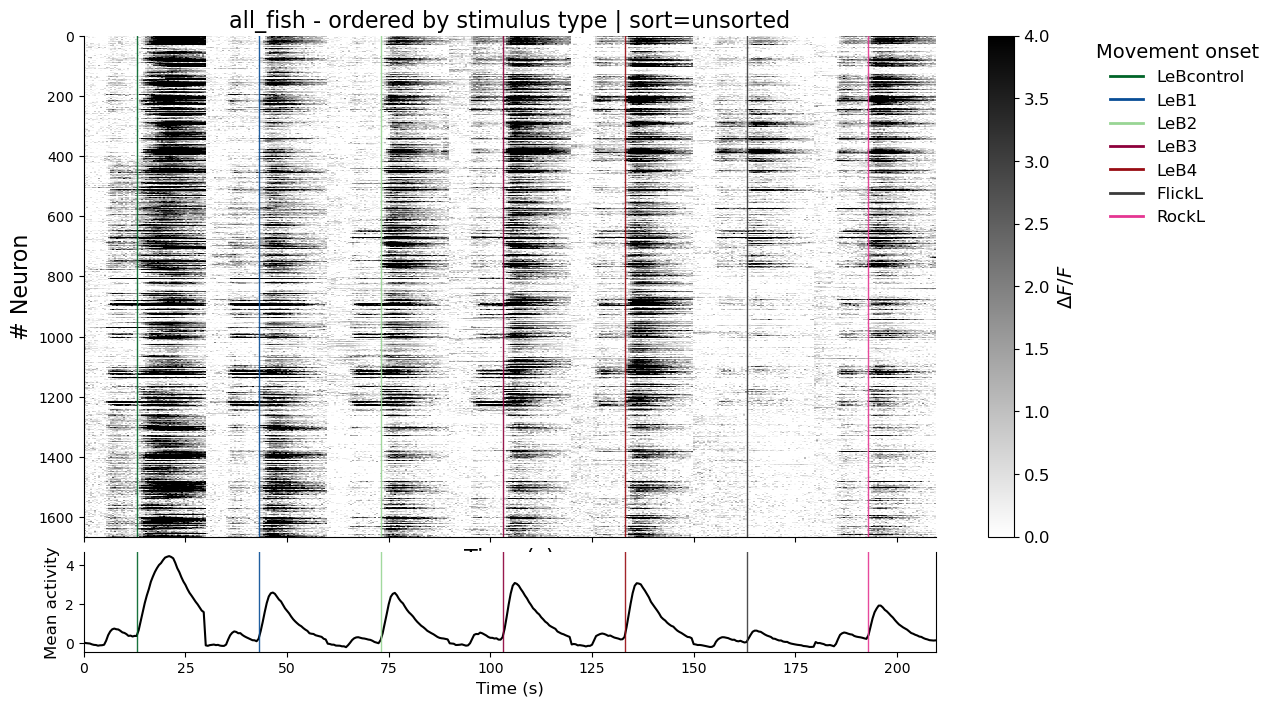

In [31]:
# Cell 09 - Plot left z-score raster
# Builds a pooled left-side z-score mean matrix and plots all fish without sorting.
# plot all fish together
#{'FlickL': 1, 'FlickR': 2, 'LeB1': 3, 'LeB2': 4, 'LeB3': 5, 'LeB4': 6, 'LeBcontrol': 7, 'RiB1': 8, 'RiB2': 9, 'RiB3': 10, 'RiB4': 11, 'RiBcontrol': 12, 'RockL': 13, 'RockR': 14}

#stim_order = [7,3,4,5,6,1,13,12,8,9,10,11,2,14]
#stim_order = [12,8,9,10,11,2,14]
stim_order = [7,3,4,5,6,1,13]
combine_mode = "mean"  # mean or concat
trace_type =  "zscore"#  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='unsorted',#,'unsorted',#,'corravg',      # or "pca", "hier", etc,unsorted, corravg
    n_clusters=3,
    random_state=0,
    neuron_order=None,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=False,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=4,
        
)

# save_path.mkdir(parents=True, exist_ok=True)
# out_png = save_path / f"{fish_id}_dfof_as_func_of_time_pca.png"
# fig.savefig(out_png, dpi=600, bbox_inches="tight")
# print("✅ Saved:", out_png)


Final matrix shape: (1665, 420)


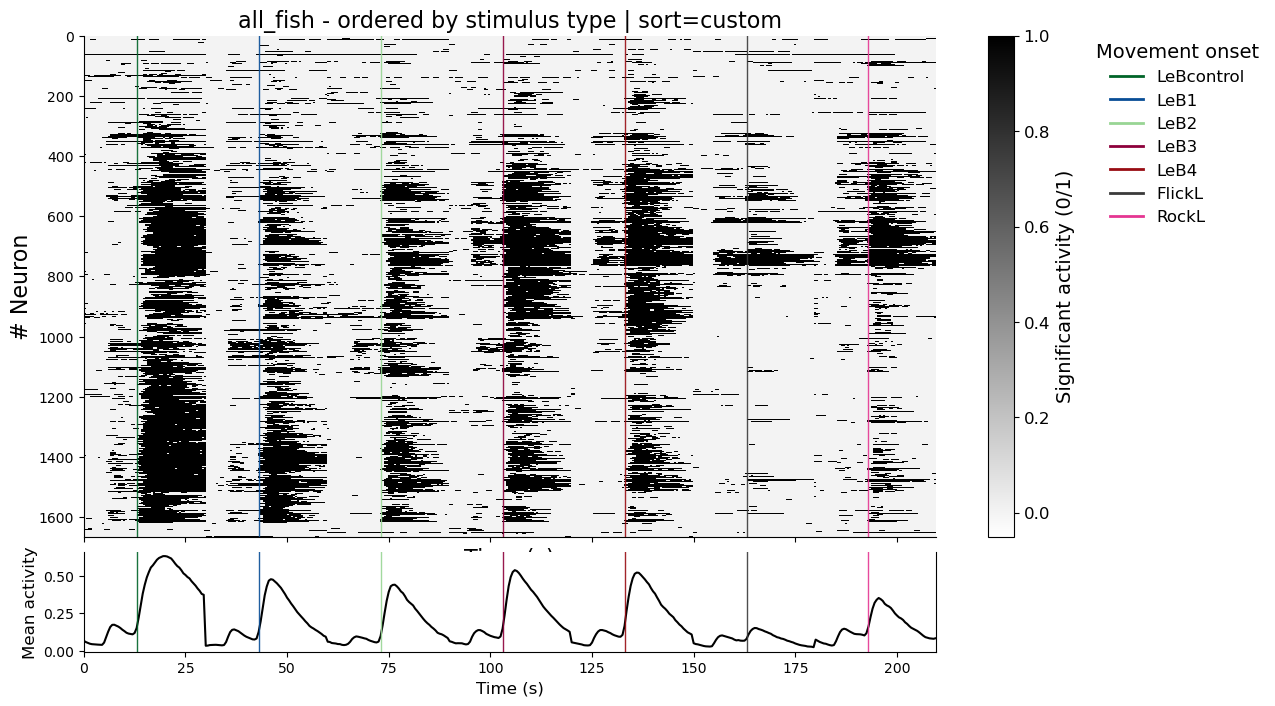

In [21]:
# Cell 10 - Plot left active raster
# Builds a pooled left-side binary raster and plots it using the previous neuron order.
stim_order = [7,3,4,5,6,1,13]
combine_mode = "mean"  # mean or concat
trace_type =  "raster"#  "dfof" ,  "raster" , zscore" -> trial_aligned_traces
M_all = build_matrix_all_fish(all_fish_data, stim_order, combine_mode=combine_mode, trace_type=trace_type)
print("Final matrix shape:", M_all.shape)

# combine_mode = "concat"   # or "mean"
# # M_all = build_matrix_all_fish(all_fish_data, stim_order,
#                               combine_mode=combine_mode)
flat_matrix_all_fish = M_all  # (time, neurons) for raster_with_stimuli
fig, ax, im, neuron_order = plott.plot_allfish_flat_raster(
    data=flat_matrix_all_fish,
    trial_aligned_traces=trial_aligned_traces,
    stim_order=stim_order,
    stimuli_id_map=stimuli_id_map,
    stimuli_durations=stimuli_durations,
    stimuli_colors=stimuli_colors,
    stimuli_linestyles=stimuli_linestyles,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    combine_mode=combine_mode,
    sort_mode='corravg',#,'unsorted',#,'corravg',      # or "pca", "hier", etc,unsorted, corravg
    n_clusters=3,
    random_state=0,
    neuron_order=neuron_order,       # or pass your own `neuron_order`
    sort_label=None,         # optional label override
    is_binary=True,         # True if you pass a 0/1 significance matrix
    show_mean_trace=True,
    figsize=(12, 8),
    fish_id="all_fish",
    vmax=1,
        
)


In [ ]:
# Cell 11 - Empty workspace
# Reserved blank cell for quick scratch work during notebook exploration.


,Bcontrol,B1,B2,B3,B4
Bcontrol,1.000000,0.703079,0.671554,0.690678,0.659916
B1,0.703079,1.000000,0.645242,0.616279,0.560755
B2,0.671554,0.645242,1.000000,0.700250,0.630435
B3,0.690678,0.616279,0.700250,1.000000,0.734793
B4,0.659916,0.560755,0.630435,0.734793,1.000000


,Bcontrol,B1,B2,B3,B4
Bcontrol,1.000000,0.594088,0.771654,0.748563,0.665475
B1,0.594088,1.000000,0.614064,0.536566,0.477383
B2,0.771654,0.614064,1.000000,0.734017,0.632605
B3,0.748563,0.536566,0.734017,1.000000,0.654839
B4,0.665475,0.477383,0.632605,0.654839,1.000000


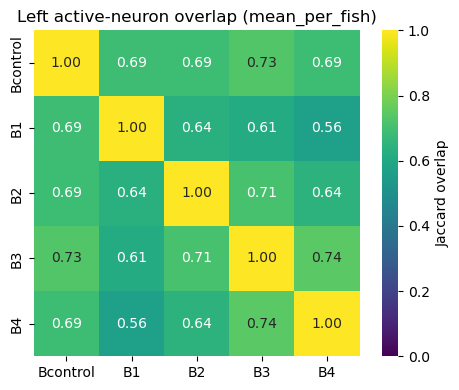

In [34]:
# Cell 12 - Overlap heatmap
# Computes active-neuron Jaccard overlap across left/right B conditions and plots one selected side.
# Step 2: active-neuron overlap across B conditions

condition_labels = ["Bcontrol", "B1", "B2", "B3", "B4"]

side_stimuli = {
    "left": [7, 3, 4, 5, 6],
    "right": [12, 8, 9, 10, 11],
}

active_matrices = build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=side_stimuli["left"] + side_stimuli["right"],
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    active_fraction_threshold=0.20,
    min_epoch_s=1.5,
    min_active_reps=2
)

overlap_results = build_active_neuron_overlap_matrices_all_fish(
    active_matrices=active_matrices,
    side_stimuli=side_stimuli,
    condition_labels=condition_labels,
)

left_overlap_matrix = overlap_results["pooled"]["left"]
right_overlap_matrix = overlap_results["pooled"]["right"]
left_overlap_matrix_mean_per_fish = overlap_results["mean_per_fish"]["left"]
right_overlap_matrix_mean_per_fish = overlap_results["mean_per_fish"]["right"]

side_to_plot = "left"  # or "right"
aggregation_to_plot = "mean_per_fish"#"pooled"  # or "mean_per_fish"
matrix_to_plot = overlap_results[aggregation_to_plot][side_to_plot]

display(left_overlap_matrix)
display(right_overlap_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matrix_to_plot,
    vmin=0,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Jaccard overlap"},
    ax=ax,
)
ax.set_title(f"{side_to_plot.capitalize()} active-neuron overlap ({aggregation_to_plot})")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()


In [18]:
# Cell 13 - Pool mean traces
# Averages trials per fish/stimulus, then concatenates per-stimulus mean traces across fish.
## Organize by Left and Rigth response....
## First Concatenate mean traces across experiments
import numpy as np

# result: concat_mean_traces[stim] -> (sum_fish n_kept_neurons_fish, win_length)
concat_mean_traces = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons = {stim: [] for stim in stimuli_ids}
concat_mean_all_neurons_norm = {stim: [] for stim in stimuli_ids}

for fid in fish_ids:
    trial_aligned_traces = all_fish_data[fid]["trial_aligned_traces"] # delta F/F 
    trial_aligned_traces_norm = all_fish_data[fid]["trial_aligned_traces_z_core"] # z-score
    kept_neuron_indices = all_fish_data[fid]["kept_neuron_indices"]

    for stim in stimuli_ids:
        X = trial_aligned_traces[stim]              # (n_neurons, win_length, n_trials)
        Xkept = X[kept_neuron_indices, :, :]        # (n_kept_fish, win_length, n_trials)
        mean_trace = np.nanmean(Xkept, axis=2)     # (n_kept_fish, win_length)
        mean_all_neurons = np.nanmean(mean_trace, axis=0)

        concat_mean_traces[stim].append(mean_trace)
        concat_mean_all_neurons[stim].append(mean_all_neurons)

        Y = trial_aligned_traces_norm[stim]        # same as X but Global Norm
        mean_trace_norm = np.nanmean(Y, axis=2)
        mean_all_neurons_norm = np.nanmean(mean_trace_norm, axis=0)

        concat_mean_all_neurons_norm[stim].append(mean_all_neurons_norm)
# stack per stimulus along the neuron axis
for stim in stimuli_ids:
    concat_mean_traces[stim] = np.vstack(concat_mean_traces[stim])
    concat_mean_all_neurons[stim] = np.vstack(concat_mean_all_neurons[stim])
    concat_mean_all_neurons_norm[stim] = np.vstack(concat_mean_all_neurons_norm[stim])
# Example:
# big_mat_FL1 = concat_mean_traces['FL1']   # shape: (all_kept_neurons_all_fish, win_length)
print(concat_mean_all_neurons[stim].shape)
print(concat_mean_traces[stim].shape)

(5, 60)
(1665, 60)


new_stimuli_ids:   [12, 8, 9, 10, 11, 2, 14]
new_stimuli_names: ['RiBcontrol', 'RiB1', 'RiB2', 'RiB3', 'RiB4', 'FlickR', 'RockR']
shape of first M: (5, 60)


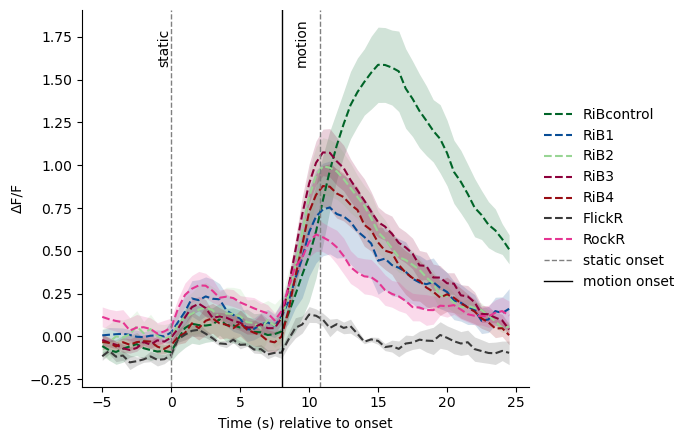

In [19]:
# Cell 14 - Plot right means
# Selects right-side stimuli and plots pooled normalized mean traces with stimulus styling.

stim_order = [12,8,9,10,11,2,14]

#stimuli_wanted = [0,1,2,3,4,7,8,9,5,6]  # positions in the list (0-based!)
stimuli_wanted = [11,7,8,9,10,1,13] ## rigth
# stimuli_wanted = [4,1,2,3] ## left
M = {}  # new dict with selected mean_traces
new_stimuli_ids = []  # new list of ids
new_stimuli_names = []  # new list of names

for pos in stimuli_wanted:
    # id in your list at that position
    stim_id = stimuli_ids[pos]
    stim_name = stimuli_names[pos]

    # take the correct array from the dict
    M[stim_id] = concat_mean_all_neurons_norm[stim_id]

    # store id and name in new lists
    new_stimuli_ids.append(stim_id)
    new_stimuli_names.append(stim_name)

print("new_stimuli_ids:  ", new_stimuli_ids)
print("new_stimuli_names:", new_stimuli_names)
# example: check one of the matrices
print("shape of first M:", M[new_stimuli_ids[0]].shape)


fig, ax, used_colors, out_path = plott.plot_stimulus_means(
    mean_traces=M,
    stimuli_ids=new_stimuli_ids,
    stimuli_names=new_stimuli_names,
    title_prefix="",
    fps_2p=fps_2p,
    t_post_s=t_post_s,
    t_pre_s=t_pre_s,
    stimuli_durations= stimuli_durations,
    plots_path=None,       # Path object or str
    prefix=None,               # e.g., "exp12_mouseA"
    dpi=600,
    save=False,
    stimuli_colors=stimuli_colors,            # <— pass styles here
    stimuli_linestyles=stimuli_linestyles,
    close_after=False,
    kept_cells = None,
    comment="jhghjg" # for saving
)



(<Figure size 1000x400 with 1 Axes>,
 array([<Axes: title={'center': 'Left'}, xlabel='Segment', ylabel='delta_integral'>],
       dtype=object))

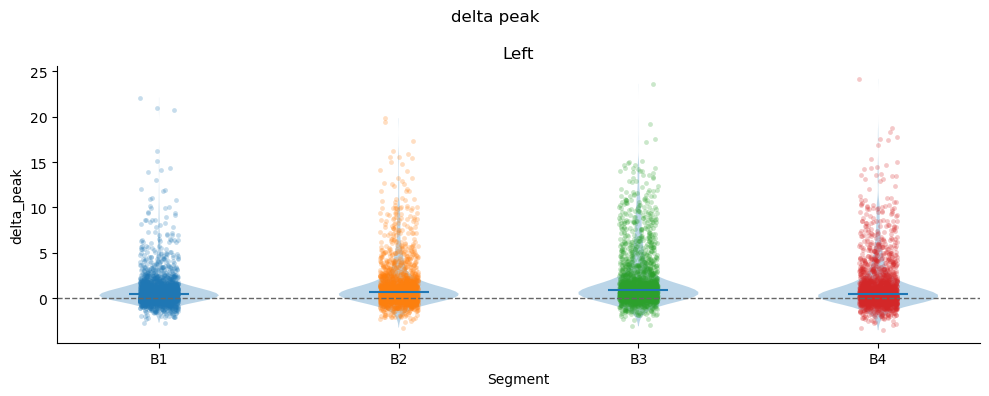

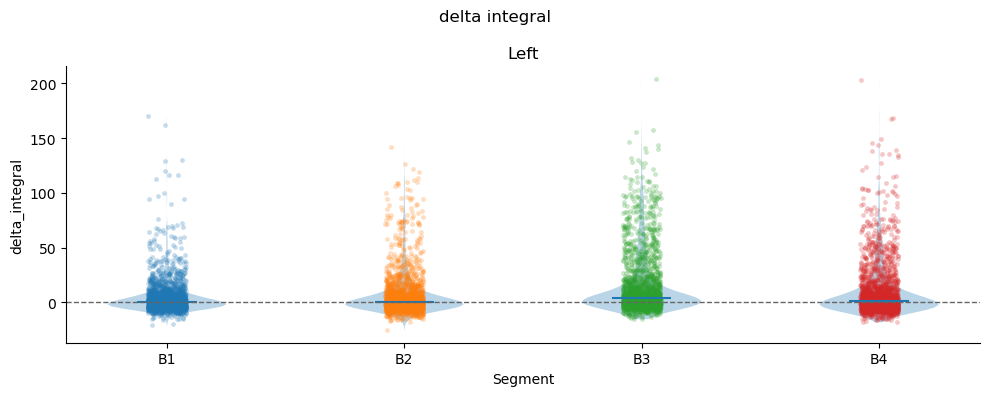

In [14]:
# Cell 15 - Motion deltas
# Computes integral and peak response deltas around motion onset for one fish and plots distributions.

import importlib
import src.analysis_tools as at
import src.plotting as plott

importlib.reload(at)
importlib.reload(plott)



delta_df = at.compute_motion_delta_integrals(
    all_fish_data[fish_id]["trial_aligned_traces_z_core"],
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    pre_motion_fixed_s=8.0,
    stimuli_id_map=all_fish_data[fish_id]["stimuli_id_map"],
    stimuli_durations=all_fish_data[fish_id]["stimuli_durations"],
    fish_id=fish_id,
)

peak_df = at.compute_motion_delta_peaks(
    all_fish_data[fish_id]["trial_aligned_traces_z_core"],
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    pre_motion_fixed_s=8.0,
    stimuli_id_map=all_fish_data[fish_id]["stimuli_id_map"],
    stimuli_durations=all_fish_data[fish_id]["stimuli_durations"],
    fish_id=fish_id,
)

#plott.plot_motion_delta_distribution(delta_df)
#plott.plot_motion_delta_distribution(peak_df, value_col="delta_peak")
plott.plot_motion_delta_distribution(peak_df, value_col="delta_peak", side="left")
plott.plot_motion_delta_distribution(delta_df, side="left")




In [ ]:
# Cell 16 - Active matrices
# Reloads multi-fish helpers and builds active-neuron matrices plus counts with stricter thresholds.
import importlib
import src.multifish_analysis as mfa
importlib.reload(mfa)



active_matrices, active_counts = mfa.build_active_neuron_matrices_all_fish(
    all_fish_data,
    tau_s=6.0,
    active_fraction_threshold=0.30,
    min_epoch_s=2.0,
    min_active_reps=2,
    expected_reps=4,
    return_counts=True,
)


,Bcontrol,B1,B2,B3,B4
Bcontrol,1.000000,0.628165,0.612520,0.636981,0.596582
B1,0.628165,1.000000,0.577693,0.551605,0.486555
B2,0.612520,0.577693,1.000000,0.659774,0.561717
B3,0.636981,0.551605,0.659774,1.000000,0.675579
B4,0.596582,0.486555,0.561717,0.675579,1.000000


,Bcontrol,B1,B2,B3,B4
Bcontrol,1.000000,0.527757,0.715152,0.688686,0.591219
B1,0.527757,1.000000,0.559708,0.458115,0.398014
B2,0.715152,0.559708,1.000000,0.668977,0.565972
B3,0.688686,0.458115,0.668977,1.000000,0.618349
B4,0.591219,0.398014,0.565972,0.618349,1.000000


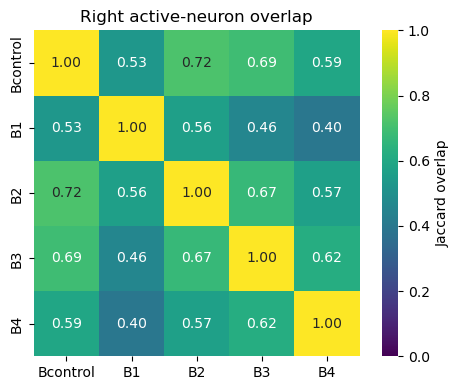

In [9]:
# Cell 17 - Pooled overlap
# Recomputes active matrices with default settings and plots pooled overlap for the chosen side.
from src.multifish_analysis import (
    build_active_neuron_matrices_all_fish,
    build_active_neuron_overlap_matrices_all_fish,
)

# Step 2: active-neuron overlap across B conditions

condition_labels = ["Bcontrol", "B1", "B2", "B3", "B4"]

side_stimuli = {
    "left": [7, 3, 4, 5, 6],
    "right": [12, 8, 9, 10, 11],
}

active_matrices = build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=side_stimuli["left"] + side_stimuli["right"],
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
)

overlap_results = build_active_neuron_overlap_matrices_all_fish(
    active_matrices=active_matrices,
    side_stimuli=side_stimuli,
    condition_labels=condition_labels,
)

left_overlap_matrix = overlap_results["pooled"]["left"]
right_overlap_matrix = overlap_results["pooled"]["right"]

side_to_plot =  "right"#"left"  # or "right"
matrix_to_plot = overlap_results["pooled"][side_to_plot]

display(left_overlap_matrix)
display(right_overlap_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    matrix_to_plot,
    vmin=0,
    vmax=1,
    square=True,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    cbar_kws={"label": "Jaccard overlap"},
    ax=ax,
)
ax.set_title(f"{side_to_plot.capitalize()} active-neuron overlap")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()


trace_matrix: (1665, 300)
decision_matrix: (1665, 5)


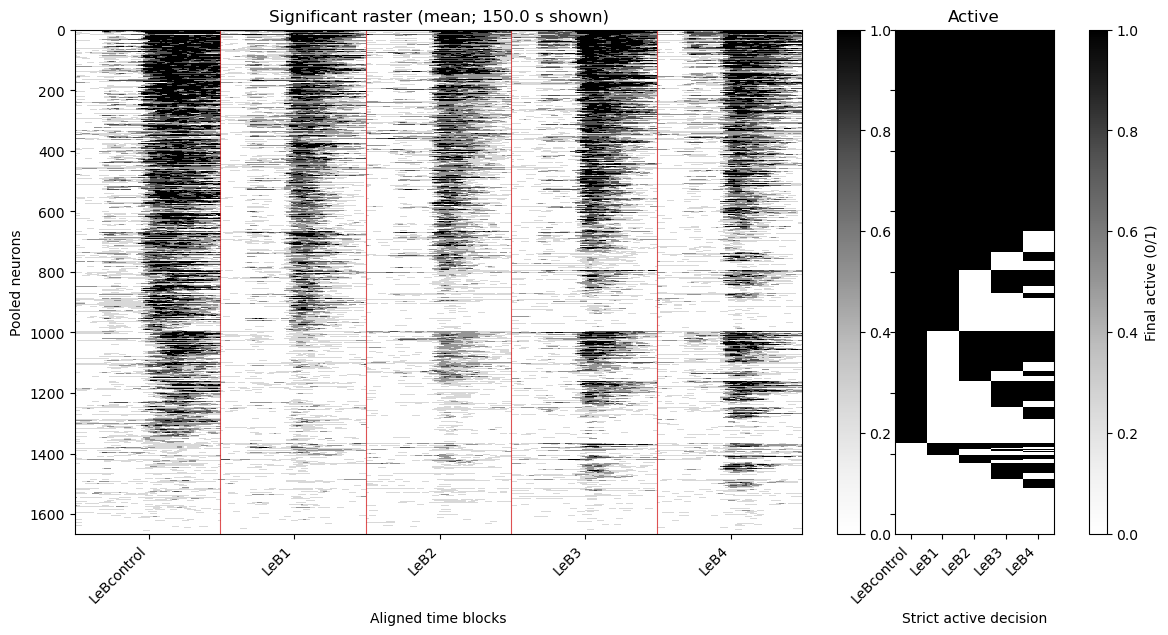

In [35]:
# Cell 18 - Decision diagnostic
# Builds and plots a pooled diagnostic comparing traces with active/inactive decisions.
from src.multifish_analysis import (
    build_active_neuron_matrices_all_fish,
    build_pooled_active_trace_diagnostic,
)

# Active-decision strictness diagnostic
# Choose any stimuli to inspect. Left B conditions shown by default.
diagnostic_stim_order = [7, 3, 4, 5, 6]  # LeBcontrol, LeB1, LeB2, LeB3, LeB4
# diagnostic_stim_order = [12, 8, 9, 10, 11]  # RiBcontrol, RiB1, RiB2, RiB3, RiB4
diagnostic_combine_mode = "mean"#"mean"  # "mean" or "concat"

active_matrices = build_active_neuron_matrices_all_fish(
    all_fish_data=all_fish_data,
    fish_ids=fish_ids,
    stim_order=diagnostic_stim_order,
    fps_2p=fps_2p,
    t_pre_s=t_pre_s,
    tau_s=6.0,
    active_fraction_threshold=0.10,
    min_epoch_s=2.0,
    min_active_reps=2,
    expected_reps=4,
)

active_trace_diagnostic = build_pooled_active_trace_diagnostic(
    all_fish_data=all_fish_data,
    active_matrices=active_matrices,
    fish_ids=fish_ids,
    stim_order=diagnostic_stim_order,
    combine_mode=diagnostic_combine_mode,
)

fig, axes, diagnostic_neuron_order = plott.plot_active_trace_decision_diagnostic(
    active_trace_diagnostic,
    fps_2p=fps_2p,
    stimuli_durations=stimuli_durations,
    t_pre_s=t_pre_s,
    sort_mode="decision_then_mean",
    figsize=(12, 7),
)

print("trace_matrix:", active_trace_diagnostic["trace_matrix"].shape)
print("decision_matrix:", active_trace_diagnostic["decision_matrix"].shape)
